In [62]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [63]:
df= pd.read_csv("/Users/Admin/Me only/DS project/Notebook/Data/gemstone.csv")

df= df.drop(columns='id')
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


# Getting X and y variables.

In [64]:
X= df.drop(columns='price')
y= df['price']

In [65]:
y.info()

<class 'pandas.Series'>
RangeIndex: 193573 entries, 0 to 193572
Series name: price
Non-Null Count   Dtype
--------------   -----
193573 non-null  int64
dtypes: int64(1)
memory usage: 1.5 MB


In [66]:
# Define which columns should be ordinal-encoded and which should be scaled
categorical_cols = X.select_dtypes(include='str').columns
numerical_cols = X.select_dtypes(exclude='str').columns


# Define the custom ranking for each ordinal variable
cut_categories = ['Fair', 'Good', 'Very Good','Premium','Ideal']
color_categories = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_categories = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

from sklearn.preprocessing import OrdinalEncoder, StandardScaler

numerical_pipeline= Pipeline(
    steps= [
        ("imputer", SimpleImputer(strategy= 'median')),
        ("scale", StandardScaler())
    ]
)

# Categorical Pipeline
cat_pipeline = Pipeline(
                steps=[
                ('imputer',SimpleImputer(strategy='most_frequent')),
                ('ord-encoder',OrdinalEncoder(categories=[cut_categories,color_categories,clarity_categories])),
                ('scaler',StandardScaler())
                ]
            )

preprocessor= ColumnTransformer(
    [
        ("num_pipeline", numerical_pipeline, numerical_cols),
        ("cat_pipeline", cat_pipeline, categorical_cols)
    ]
)


In [67]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X,y,test_size=0.2,random_state=42)

In [71]:
xtrain = pd.DataFrame(preprocessor.fit_transform(xtrain), columns= preprocessor.get_feature_names_out())
xtest = pd.DataFrame(preprocessor.transform(xtest),columns=preprocessor.get_feature_names_out())

In [72]:
xtrain

,num_pipeline__carat,num_pipeline__depth,num_pipeline__table,num_pipeline__x,num_pipeline__y,num_pipeline__z,cat_pipeline__cut,cat_pipeline__color,cat_pipeline__clarity
0,-1.016395,-0.204317,0.402608,-1.202472,-1.187395,-1.194148,-0.132842,-0.936018,-0.648950
1,0.882396,0.720758,-0.118536,0.985177,0.941823,1.036109,-0.132842,-0.320002,0.017052
2,1.529711,0.350728,-1.160823,1.426308,1.394848,1.441611,0.872563,1.528047,0.017052
3,1.896523,0.073206,0.923751,1.741402,1.711965,1.702290,-0.132842,1.528047,-1.314953
4,0.450852,1.738340,1.444895,0.562052,0.525040,0.703019,-2.143651,0.912031,0.017052
...,...,...,...,...,...,...,...,...,...
154853,-0.628006,-1.499421,1.966038,-0.545277,-0.516918,-0.643825,-1.138246,-0.936018,-0.648950
154854,2.414375,0.443236,2.487182,1.921455,1.875054,1.934005,-1.138246,-0.320002,-0.648950
154855,0.925550,0.905773,0.402608,0.994180,0.923702,1.050591,-0.132842,0.296015,0.017052
154856,-1.037972,-0.666854,-0.639679,-1.211475,-1.196455,-1.252077,-1.138246,0.296015,2.015061


Create a function to give score after model training.

In [119]:
def model_score(true, predicted):
    r2= r2_score(true, predicted)
    mae= mean_absolute_error(true, predicted)
    mse= mean_squared_error(true, predicted)
    rmse= np.sqrt(mse)

    return r2, mae, rmse

In [75]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

In [79]:
list(models.values())[1]

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [120]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list= []
r2_scores= []

for i in range(len(list(models))):
    model= list(models.values())[i]

    model.fit(xtrain, ytrain.values.flatten())

    # Make predictions
    y_train_pred = model.predict(xtrain)
    y_test_pred = model.predict(xtest)

    # Evaluate Train and Test dataset
    model_train_r2 ,model_train_mae, model_train_rmse = model_score(ytrain, y_train_pred)

    model_test_r2 , model_test_mae, model_test_rmse = model_score(ytest, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_scores.append(model_test_r2)
    
    print('='*35)
    print('\n')


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 1016.9490
- Mean Absolute Error: 677.1656
- R2 Score: 0.9366
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1006.6010
- Mean Absolute Error: 671.5856
- R2 Score: 0.9373


Lasso
Model performance for Training set
- Root Mean Squared Error: 1017.0718
- Mean Absolute Error: 678.3145
- R2 Score: 0.9366
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1006.8716
- Mean Absolute Error: 672.8635
- R2 Score: 0.9373


Ridge
Model performance for Training set
- Root Mean Squared Error: 1016.9491
- Mean Absolute Error: 677.1925
- R2 Score: 0.9366
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1006.6062
- Mean Absolute Error: 671.6137
- R2 Score: 0.9373


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 545.6538
- Mean Absolute Error: 285.8169
- R2 Sco

In [121]:
list(zip(model_list, r2_scores))

[('Linear Regression', 0.9372975155452961),
 ('Lasso', 0.9372637996466201),
 ('Ridge', 0.937296862070098),
 ('K-Neighbors Regressor', 0.9721140416974132),
 ('Decision Tree', 0.9569639934088888),
 ('Random Forest Regressor', 0.9771710228919193),
 ('XGBRegressor', 0.9788106083869934),
 ('CatBoosting Regressor', 0.9791856803920621),
 ('AdaBoost Regressor', 0.8887000124847221)]

In [122]:
model_selection= pd.DataFrame(zip(model_list, r2_scores), columns=['Model_list', 'r2_scores']).sort_values(by= "r2_scores", ascending= False)

In [123]:
model_selection

,Model_list,r2_scores
7,CatBoosting Regressor,0.979186
6,XGBRegressor,0.978811
5,Random Forest Regressor,0.977171
3,K-Neighbors Regressor,0.972114
4,Decision Tree,0.956964
0,Linear Regression,0.937298
2,Ridge,0.937297
1,Lasso,0.937264
8,AdaBoost Regressor,0.888700


From this we found that Catboost is good among the algorithms, So we gonna Tune it using hyperparameter tunning.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [106]:
#initiating CatBoost

cbr= CatBoostRegressor(verbose= True)

params= {
    'depth': [5,6,7,8,9,10],
    'learning_rate':[0.0001, 0.001, 0.01, 0.01, 0.02, 0.03],
    'iterations': [10,100,200,400,500,600]
}

RSCV= RandomizedSearchCV(cbr, params, cv= 5, n_jobs=-1, scoring= "r2")


RSCV.fit(xtrain, ytrain.values.ravel())


# Print the tuned parameters and score
print(RSCV.best_params_)
print(RSCV.best_score_)

0:	learn: 4038.5471529	total: 62.4ms	remaining: 37.3s
1:	learn: 4038.1731964	total: 66.7ms	remaining: 19.9s
2:	learn: 4037.8003390	total: 74ms	remaining: 14.7s
3:	learn: 4037.4306827	total: 96.7ms	remaining: 14.4s
0:	learn: 4036.3190579	total: 80ms	remaining: 47.9s
0:	learn: 3925.2024591	total: 88.8ms	remaining: 8.79s
0:	learn: 4033.9695089	total: 83.2ms	remaining: 49.9s
0:	learn: 3924.9729277	total: 88.4ms	remaining: 8.76s
0:	learn: 3926.6559795	total: 92.2ms	remaining: 9.13s
0:	learn: 4038.8287262	total: 88.9ms	remaining: 53.2s
0:	learn: 4040.3017539	total: 92.9ms	remaining: 55.6s
1:	learn: 4035.9446977	total: 111ms	remaining: 33.1s
1:	learn: 4033.5957219	total: 111ms	remaining: 33.2s
4:	learn: 4037.0575433	total: 140ms	remaining: 16.6s
1:	learn: 3814.7956198	total: 128ms	remaining: 6.26s
1:	learn: 4039.9290512	total: 125ms	remaining: 37.4s
1:	learn: 3814.5621317	total: 132ms	remaining: 6.44s
1:	learn: 4038.4542072	total: 128ms	remaining: 38.3s
1:	learn: 3815.9324613	total: 135ms	rem

In [149]:
def print_evaluated_results(model,xtrain,ytrain,xtest,ytest):
    ytrain_pred = model.predict(xtrain)
    ytest_pred = model.predict(xtest)

    # Evaluate Train and Test dataset
    model_train_r2 ,model_train_mae, model_train_rmse = model_score(ytrain, y_train_pred)
    
    model_test_r2 , model_test_mae, model_test_rmse = model_score(ytest, y_test_pred)

    # Printing results
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

In [150]:
best_cbr = RSCV.best_estimator_
print_evaluated_results(best_cbr,xtrain,ytrain,xtest,ytest)


Model performance for Training set
- Root Mean Squared Error: 1338.3023
- Mean Absolute Error: 925.8438
- R2 Score: 0.8902
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1341.1042
- Mean Absolute Error: 924.6096
- R2 Score: 0.8887


Tuning XGBRegressor

In [144]:
XGB= XGBRegressor()

params= {
    'learning_rate' : [0.001,0.01,0.10,0.15,0.20,0.30],
    'max_depth' : [ 3, 4, 5, 6, 8, 10, 12, 15],
    'min_child_weight' : [ 1, 3, 5, 7 ],
    'gamma': [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
    'colsample_bytree' : [ 0.3, 0.4, 0.5 , 0.7 ],
    'n_estimators':[300,400,500,600]
}


RSGB= RandomizedSearchCV(XGB, param_distributions= params, verbose= 1, random_state= 42, n_jobs=-1, cv= 5)

RSGB.fit(xtrain, ytrain.values.ravel())



Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/Admin/Me only/DS project/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.3, 0.4, ...], 'gamma': [0.0, 0.1, ...], 'learning_rate': [0.001, 0.01, ...], 'max_depth': [3, 4, ...], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturn

In [145]:
print(RSGB.best_params_)
print(RSGB.best_score_)


print_evaluated_results(RSGB.best_estimator_, xtrain, ytrain, xtest, ytest)

{'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.2, 'gamma': 0.4, 'colsample_bytree': 0.5}
0.9792653918266296
Model performance for Training set
- Root Mean Squared Error: 1338.3023
- Mean Absolute Error: 925.8438
- R2 Score: 0.8902
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1341.1042
- Mean Absolute Error: 924.6096
- R2 Score: 0.8887


In [137]:
from sklearn.model_selection import GridSearchCV
# Initialize knn
knn = KNeighborsRegressor()

# parameters
k_range = list(range(2, 31))
param_grid = dict(n_neighbors=k_range)

# Fitting the cvmodel
grid = GridSearchCV(knn, param_grid, cv=5, scoring='r2',n_jobs=-1)
grid.fit(xtrain, ytrain)

# Print the tuned parameters and score
print(grid.best_params_)
print(grid.best_score_)

{'n_neighbors': 16}
0.9736030120960839


In [146]:
best_knn= grid.best_estimator_

In [148]:
print_evaluated_results(best_knn, xtrain, ytrain, xtest, ytest)

Model performance for Training set
- Root Mean Squared Error: 1338.3023
- Mean Absolute Error: 925.8438
- R2 Score: 0.8902
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1341.1042
- Mean Absolute Error: 924.6096
- R2 Score: 0.8887


In [152]:
from sklearn.ensemble import VotingRegressor

er = VotingRegressor([('cbr',best_cbr),('knn',best_knn),('xgb',XGBRegressor())], weights=[3,1,2])
er.fit(xtrain, ytrain.values.flatten())

print_evaluated_results(er,xtrain,ytrain,xtest,ytest)

0:	learn: 3965.2366670	total: 8.23ms	remaining: 4.93s
1:	learn: 3895.2076220	total: 16.4ms	remaining: 4.91s
2:	learn: 3826.6524294	total: 22.4ms	remaining: 4.46s
3:	learn: 3758.5637257	total: 25.4ms	remaining: 3.78s
4:	learn: 3691.7984745	total: 28.4ms	remaining: 3.38s
5:	learn: 3626.3055707	total: 31.3ms	remaining: 3.1s
6:	learn: 3562.8583243	total: 34.8ms	remaining: 2.95s
7:	learn: 3500.8240272	total: 40.3ms	remaining: 2.98s
8:	learn: 3439.8416805	total: 45.5ms	remaining: 2.99s
9:	learn: 3380.6568728	total: 49.1ms	remaining: 2.9s
10:	learn: 3322.0240765	total: 52ms	remaining: 2.79s
11:	learn: 3264.8270705	total: 55.3ms	remaining: 2.71s
12:	learn: 3207.8001611	total: 58.4ms	remaining: 2.63s
13:	learn: 3151.5304303	total: 61.7ms	remaining: 2.58s
14:	learn: 3097.6478715	total: 64.8ms	remaining: 2.52s
15:	learn: 3044.8907560	total: 69ms	remaining: 2.52s
16:	learn: 2991.5346092	total: 74.6ms	remaining: 2.56s
17:	learn: 2939.7995213	total: 78.8ms	remaining: 2.55s
18:	learn: 2890.4429765	to

num_pipeline__carat      28.739524
num_pipeline__y          18.964626
num_pipeline__z          18.495078
num_pipeline__x          15.652816
cat_pipeline__clarity    10.885568
cat_pipeline__color       7.097284
cat_pipeline__cut         0.130347
num_pipeline__depth       0.018589
num_pipeline__table       0.016168
dtype: float64




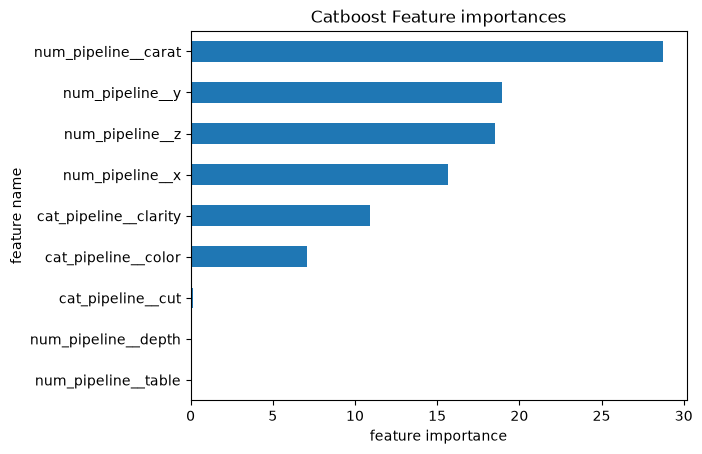

In [153]:
feature_imp = best_cbr.feature_importances_
feature_nm = best_cbr.feature_names_
imp_series = pd.Series(feature_imp)
imp_series.index = feature_nm
print(imp_series.sort_values(ascending=False))
print('\n')
imp_series.sort_values().plot(kind='barh',
                              xlabel='feature importance',
                              ylabel='feature name',
                              title='Catboost Feature importances')
plt.show()

Index(['num_pipeline__carat', 'num_pipeline__depth', 'num_pipeline__table',
       'num_pipeline__x', 'num_pipeline__y', 'num_pipeline__z',
       'cat_pipeline__cut', 'cat_pipeline__color', 'cat_pipeline__clarity'],
      dtype='str')